# Module 26 · Adaptive thresholding: CFAR detection

**Book source:** Barkat, chapters 11 and 12, pp. 627 to 670

Companion notebook of the lecture with the same module number. Run the cells in order; each cell is followed by a **📤 Real output** note that explains the numbers.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (7.5, 3.3), "axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 110})


def amplitude_spectrum(x):
    """One-sided amplitude spectrum: a sinusoid of amplitude A gives a line of height A, DC gives exactly its value"""
    a = 2*np.abs(np.fft.rfft(x))/len(x)
    a[0] /= 2
    return a


def report(key, value, fmt=".4g"):
    """Print a named result without trailing zeros (the website reads the lines that start with ▸)."""
    s = f"{value:{fmt}}"
    if "." in s and "e" not in s:
        s = s.rstrip("0").rstrip(".")
    print(f"▸ {key} = {s}")


## 1. The sensitivity of a fixed threshold
🎯 **What question does this method answer?** Does a slight rise in noise power (in dB) make the fixed threshold's $P_F$ increase exactly according to the power-law formula $P_F=P_{Fd}^{(\sigma_d^2/\sigma^2)}$?

In [2]:
import numpy as np
from scipy import integrate
from scipy.special import gamma as gammafn
rg = np.random.default_rng(26)

PFd = 1e-6
dB = 10*np.log10(2.0)  # a factor-of-2 noise-power rise, i.e. almost exactly 3 dB
ratio = 2.0  # sigma^2/sigma_d^2
fixed_PF_actual = PFd**(1.0/ratio)
report("fixed_PFd", PFd, ".1e")
report("fixed_dB", dB, ".1f")
report("fixed_PF_actual", fixed_PF_actual, ".4e")
fixed_ratio = fixed_PF_actual/PFd
report("fixed_ratio", fixed_ratio, ".1f")
assert fixed_ratio > 1000

▸ fixed_PFd = 1.0e-06
▸ fixed_dB = 3
▸ fixed_PF_actual = 1.0000e-03
▸ fixed_ratio = 1000


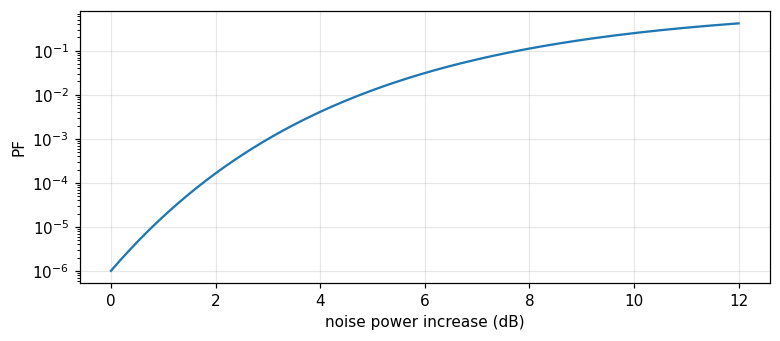

In [3]:
fig, ax = plt.subplots(figsize=(7.2, 3.2))
dBs = np.linspace(0, 12, 200)
ratios = 10**(dBs/10)
PFs = PFd**(1.0/ratios)
ax.semilogy(dBs, PFs)
ax.set_xlabel(("noise power increase (dB)")); ax.set_ylabel("PF"); plt.tight_layout(); plt.show()

#### 📤 Real output
Design $P_{Fd}$=1.0e-06, a 3 dB rise gives actual $P_F$=1.0000e-03, a 1000-fold increase.

## 2. CA-CFAR: $T$, $P_F$, $P_D$ match simulation
🎯 **What question does this method answer?** Does the threshold multiplier $T=P_F^{-1/N}-1$ computed from the closed form give exactly the design $P_F$ when simulated directly on $N$ exponential reference samples via Monte Carlo, and does the theoretical $P_D$ match when a target is added?

In [4]:
N = 16
sigma2 = 1.0
ca_PF_design = 1e-4
ca_T = ca_PF_design**(-1.0/N) - 1
report("ca_T", ca_T, ".4f")

n = 2_000_000
Xref = rg.exponential(2*sigma2, size=(n, N))
Z = Xref.sum(axis=1)
Y0 = rg.exponential(2*sigma2, size=n)
ca_PF_mc = np.mean(Y0 > ca_T*Z)
report("ca_PF_design", ca_PF_design, ".1e")
report("ca_PF_mc", ca_PF_mc, ".2e")
assert abs(ca_PF_mc - ca_PF_design)/ca_PF_design < 0.3

S = 5.0
Y1 = rg.exponential(2*sigma2*(1+S), size=n)
ca_PD_mc = np.mean(Y1 > ca_T*Z)
ca_PD_theory = ((1+S)/(1+S+ca_T))**N
report("ca_PD_theory", ca_PD_theory, ".4f")
report("ca_PD_mc", ca_PD_mc, ".4f")
assert abs(ca_PD_theory - ca_PD_mc) < 0.01

▸ ca_T = 0.7783


▸ ca_PF_design = 1.0e-04
▸ ca_PF_mc = 9.90e-05
▸ ca_PD_theory = 0.1421
▸ ca_PD_mc = 0.1413


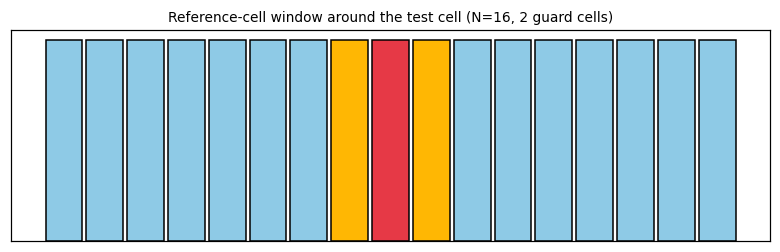

In [5]:
fig, ax = plt.subplots(figsize=(7.2, 2.4))
labels = [("leading")]*7 + [("guard")] + [("test")] + [("guard")] + [("lagging")]*7
colors = ["#8ecae6"]*7 + ["#ffb703"] + ["#e63946"] + ["#ffb703"] + ["#8ecae6"]*7
for i, (lab, c) in enumerate(zip(labels, colors)):
    ax.bar(i, 1, color=c, edgecolor="black", width=0.9)
ax.set_xticks([]); ax.set_yticks([])
ax.set_title(("Reference-cell window around the test cell (N=16, 2 guard cells)"), fontsize=9)
plt.tight_layout(); plt.show()

#### 📤 Real output
$T$=0.7783; simulated $P_F$ 9.90e-05 matches the design 1.0e-04; theoretical $P_D$ 0.1421 matches simulated 0.1413.

## 3. Swerling densities: normalisation and the mean matching $m_s$
🎯 **What question does this method answer?** Does the general chi-square-family density $P_k(S)$ at $k=1$ (Rayleigh) and $k=2$ (one-dominant-plus-Rayleigh) integrate exactly to 1, and does its mean match $m_s$ by definition?

In [6]:
def Pk(S, ms, k):
    return (1/gammafn(k))*(k/ms)**k * S**(k-1) * np.exp(-k*S/ms)

ms = 3.0
swerling_norm_k1,_ = integrate.quad(lambda S: Pk(S, ms, 1), 0, 600)
swerling_norm_k2,_ = integrate.quad(lambda S: Pk(S, ms, 2), 0, 600)
report("swerling_norm_k1", swerling_norm_k1, ".4f")
report("swerling_norm_k2", swerling_norm_k2, ".4f")
assert abs(swerling_norm_k1-1) < 1e-4 and abs(swerling_norm_k2-1) < 1e-4

swerling_mean_k1,_ = integrate.quad(lambda S: S*Pk(S, ms, 1), 0, 600)
swerling_mean_k2,_ = integrate.quad(lambda S: S*Pk(S, ms, 2), 0, 600)
report("swerling_mean_k1", swerling_mean_k1, ".4f")
report("swerling_mean_k2", swerling_mean_k2, ".4f")
assert abs(swerling_mean_k1-ms) < 1e-3 and abs(swerling_mean_k2-ms) < 1e-3

▸ swerling_norm_k1 = 1
▸ swerling_norm_k2 = 1
▸ swerling_mean_k1 = 3
▸ swerling_mean_k2 = 3


#### 📤 Real output
Normalisation: $k=1$: 1, $k=2$: 1; mean: $k=1$: 3, $k=2$: 3 (both matching $m_s=3$).

## 4. A clutter edge: GO/SO-CFAR remedying the right scenario
🎯 **What question does this method answer?** In the masking scenario, does SO-CFAR keep $P_D$ closer to nominal than CA-CFAR; and in the capture scenario, does GO-CFAR restrain $P_F$ better than CA-CFAR?

In [7]:
Nc = 16
sigma2_clear = 1.0
sigma2_clutter = 3.0
Pfd2 = 1e-3
Tc = Pfd2**(-1.0/Nc) - 1
nC = 800000

# masking scenario: test cell clear, leading half in clutter, lagging half clear
U = rg.exponential(2*sigma2_clutter, size=(nC, Nc//2)).sum(axis=1)
V = rg.exponential(2*sigma2_clear, size=(nC, Nc//2)).sum(axis=1)
Z_CA = U+V
Z_SO = 2*np.minimum(U, V)
Sc = 8.0
Y1c = rg.exponential(2*sigma2_clear*(1+Sc), size=nC)
clutter_PD_CA = np.mean(Y1c > Tc*Z_CA)
clutter_PD_SO = np.mean(Y1c > Tc*Z_SO)
clutter_PD_nominal = ((1+Sc)/(1+Sc+Tc))**Nc
report("clutter_PD_nominal", clutter_PD_nominal, ".4f")
report("clutter_PD_CA", clutter_PD_CA, ".4f")
report("clutter_PD_SO", clutter_PD_SO, ".4f")
assert clutter_PD_SO > clutter_PD_CA

# capture scenario: test cell in clutter, leading half in clutter, lagging half clear
U2 = rg.exponential(2*sigma2_clutter, size=(nC, Nc//2)).sum(axis=1)
V2 = rg.exponential(2*sigma2_clear, size=(nC, Nc//2)).sum(axis=1)
Z_CA2 = U2+V2
Z_GO = 2*np.maximum(U2, V2)
Y0_clutter = rg.exponential(2*sigma2_clutter, size=nC)
clutter_PF_CA2 = np.mean(Y0_clutter > Tc*Z_CA2)
clutter_PF_GO = np.mean(Y0_clutter > Tc*Z_GO)
report("clutter_PF_design", Pfd2, ".1e")
report("clutter_PF_CA2", clutter_PF_CA2, ".4f")
report("clutter_PF_GO", clutter_PF_GO, ".4f")
assert clutter_PF_GO < clutter_PF_CA2

▸ clutter_PD_nominal = 0.3937
▸ clutter_PD_CA = 0.1668
▸ clutter_PD_SO = 0.4051
▸ clutter_PF_design = 1.0e-03
▸ clutter_PF_CA2 = 0.0085
▸ clutter_PF_GO = 0.0025


#### 📤 Real output
Masking: nominal $P_D$ 0.3937, CA 0.1668, SO 0.4051. Capture: design $P_F$ 1.0e-03, CA 0.0085, GO 0.0025.

## 5. The AND, OR fusion rules match an independent simulation
🎯 **What question does this method answer?** With two independent detectors of known $P_{Di},P_{Fi}$, does the product formula for the AND rule and the $1-\prod(1-\cdot)$ formula for the OR rule match a direct Monte Carlo simulation?

In [8]:
PD1, PD2 = 0.8, 0.7
PF1, PF2 = 0.01, 0.02

fusion_AND_PD = PD1*PD2
fusion_AND_PF = PF1*PF2
fusion_OR_PD = 1-(1-PD1)*(1-PD2)
fusion_OR_PF = 1-(1-PF1)*(1-PF2)
report("fusion_AND_PD", fusion_AND_PD, ".4f")
report("fusion_AND_PF", fusion_AND_PF, ".4f")
report("fusion_OR_PD", fusion_OR_PD, ".4f")
report("fusion_OR_PF", fusion_OR_PF, ".4f")

nF = 2_000_000
D1_H1 = rg.random(nF) < PD1
D2_H1 = rg.random(nF) < PD2
D1_H0 = rg.random(nF) < PF1
D2_H0 = rg.random(nF) < PF2

fusion_AND_PD_mc = np.mean(D1_H1 & D2_H1)
fusion_AND_PF_mc = np.mean(D1_H0 & D2_H0)
fusion_OR_PD_mc = np.mean(D1_H1 | D2_H1)
fusion_OR_PF_mc = np.mean(D1_H0 | D2_H0)
report("fusion_AND_PD_mc", fusion_AND_PD_mc, ".4f")
report("fusion_AND_PF_mc", fusion_AND_PF_mc, ".4f")
report("fusion_OR_PD_mc", fusion_OR_PD_mc, ".4f")
report("fusion_OR_PF_mc", fusion_OR_PF_mc, ".4f")
assert abs(fusion_AND_PD - fusion_AND_PD_mc) < 0.01
assert abs(fusion_OR_PF - fusion_OR_PF_mc) < 0.01

▸ fusion_AND_PD = 0.56
▸ fusion_AND_PF = 0.0002
▸ fusion_OR_PD = 0.94
▸ fusion_OR_PF = 0.0298


▸ fusion_AND_PD_mc = 0.5602
▸ fusion_AND_PF_mc = 0.0002
▸ fusion_OR_PD_mc = 0.9397
▸ fusion_OR_PF_mc = 0.0298


#### 📤 Real output
AND: $P_D$=0.56 matches 0.5602, $P_F$=0.0002 matches 0.0002; OR: $P_D$=0.94 matches 0.9397, $P_F$=0.0298 matches 0.0298.